Using file: FishTank20200130_153857_tracking_results.h5
Exp_id: 2
Fightbout: [     2  31500 175400 143900]
dpp shape (143900,)
[0.8249462 2.8329833 7.223997 ]
Measurement noise trace: -0.035904984921216965.
Automatically selecting force inference parameters: M_mode Ito, G_mode trapeze (Lambda trace: -0.035904984921216965). 

  --- StochasticForceInference Report --- 
Average diffusion tensor:
 [[ 0.6053308  -0.00215583  0.00287769]
 [-0.00215583  0.9131795   0.2030067 ]
 [ 0.00287769  0.2030067   0.9759786 ]]
Measurement noise tensor:
 [[-1.0864083e-02  8.1357612e-05 -6.4580076e-05]
 [ 8.1357604e-05 -1.1697030e-02 -1.7526885e-03]
 [-6.4580105e-05 -1.7526883e-03 -1.3343873e-02]]
Force estimated information: 40033.91015625
Force: estimated normalized mean squared error (sampling only): 0.0041964356787502766
Force model:
 +27.43 (±2.009) b₀ +5.663 (±18.88) b₁ +96.37 (±18.99) b₂ -13.8 (±3.348) b₃ +0.331 (±13) b₄ -63.07 (±13.37) b₅ +39.8 (±3.075) b₆ +23.28 (±3.092) b₇ +1.025 (±18.88) b₈ -93

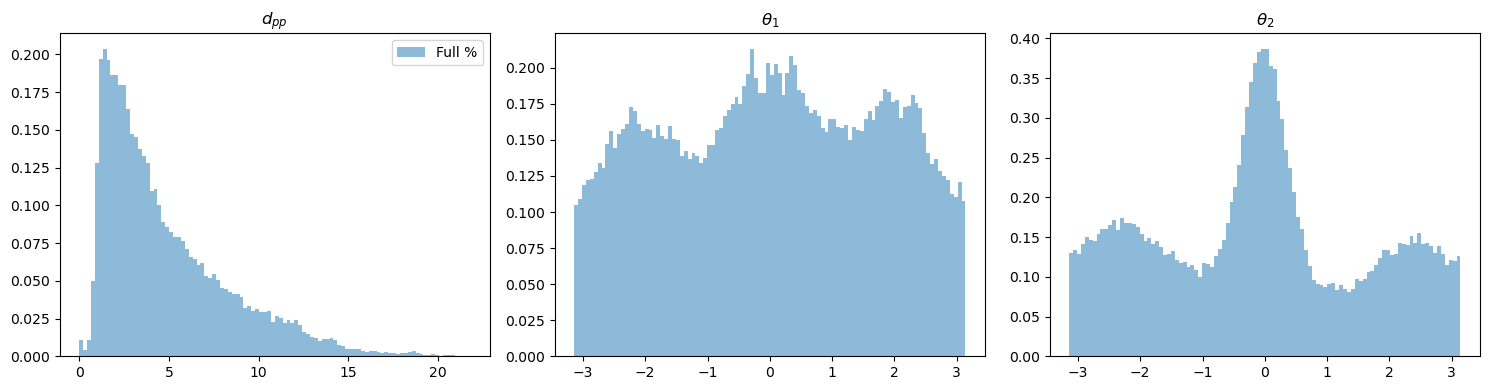

0.16206617262550208


'\njs_first = average_js_score(X_first[:,0],wrap_pi(X_first[:,1]),wrap_pi(X_first[:,2]),traj_sim_first)\njs_last = average_js_score(X_last[:,0],wrap_pi(X_last[:,1]),wrap_pi(X_last[:,2]),traj_sim_last)\n\nall_endpoints, all_forces, startpoints, accept_rate = Find_endpoints(S_first, outdir,tag="first_half", exp_id=Exp_id, fight_id=1)\nall_endpoints_last, all_forces_last, startpoints_last, accept_rate_last = Find_endpoints(S_last,outdir, tag="last_half", exp_id=Exp_id, fight_id=1)\n\n\nwith open(os.path.join(outdir, "metadata.txt"), "w") as f:\n    f.write(f"path: {path}\n")\n    f.write(f"file: {os.path.basename(path)}\n")\n    f.write(f"Exp_id: {Exp_id}\n")\n    f.write(f"fightnumber_used: {fight_id}\n")\n    f.write(f"fightbout: {fightbout}\n")\n    f.write("\n")\n\n\n    f.write("lambda_common (q1, q50, q95):\n")\n    f.write(f"{np.array(lam_common)}\n")\n\n    f.write("\n")\n    f.write("Jensen-Shannon scores:\n")\n    f.write(f"JS_first_half: {js_first}\n")\n    f.write(f"JS_last_ha

In [73]:
import os
import numpy as np
import h5py
import matplotlib.pyplot as plt
import glob, os
import SFI
import SFI.OLI_bases
import jax.numpy as jnp
from jax import random
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import pandas as pd
import pickle
from scipy.spatial.distance import jensenshannon
import csv

def get_experimentID_fightbouts(path):

    tracking_folder = os.path.dirname(path)

    loadpaths = glob.glob(os.path.join(tracking_folder, "*results.h5"))
    loadpaths.sort()

    expNames = [os.path.basename(p)[:23] for p in loadpaths]

    target_expName = os.path.basename(path)[:23]
    expIdx = expNames.index(target_expName)

    fightbout_path = os.path.join(tracking_folder, "fightBouts.h5")

    with h5py.File(fightbout_path, "r") as j:
        fb = j["fight_bout_info_noDurThresh"][:]

    fightbouts = fb[fb[:, 0].astype(int) == expIdx]


    return expIdx, fightbouts
#EXP_id , fightbout = get_experimentID_fightbouts( "/Users/marindevandijk/Documents/CLS 2025/Thesis/Coding/ZebraFish_project/Data/tracking_results/FishTank20200213_154940_tracking_results.h5")

def prepare_data(path,fightnumber = 0,infight =True):
    "Prepare the data make it ready to calculate dpp,theta1 and theta2"
    "if infight = True return data with only the frist infight bouts otherwise it returns total trajectory  "

    path = path
    f = h5py.File(path, "r")

    X = f["tracks_3D_smooth"][:]
    EXP_id , fightbout = get_experimentID_fightbouts(path)
    if infight == True and fightbout.size > 0:
        X_coordinates = X[fightbout[fightnumber,1]:fightbout[fightnumber,2],:,:,:]
    else:
        X_coordinates = X.copy()
    return X_coordinates,fightbout[fightnumber], EXP_id


def wrap_pi(a):
    return (a + np.pi) % (2*np.pi) - np.pi

def calculate_theta(fish0,fish1):
    vector_fish0 = (fish0[:,0,:] - fish0[:,1,:]) # difference in heading of head and pec
    orientation_fish0 = vector_fish0/np.linalg.norm(vector_fish0, axis=1, keepdims=True)

    theta0 = np.arctan2(orientation_fish0[:, 1],  orientation_fish0[:, 0])

    r_01 = fish1[:,1,:] - fish0[:,1,:] 
    phi_01 = np.arctan2(r_01[:,1],r_01[:,0]) #dy,dx

    theta0 = np.arctan2(vector_fish0[:, 1], vector_fish0[:, 0])
    psi_01 = phi_01 - theta0
    psi_01 = wrap_pi(psi_01) # wrap interval from -pi to pi
    return psi_01

def calculate_variables(coordinates_cleaned):
    "input are the coordinates and returns dpp,theta_i and theta_j"

    fish_i = coordinates_cleaned[:,0,:,:]
    fish_j = coordinates_cleaned[:,1,:,:]

    pec_fish_i = coordinates_cleaned[:,0,1,:]
    pec_fish_j = coordinates_cleaned[:,1,1,:]

    d_pp = np.linalg.norm((pec_fish_j-pec_fish_i), axis=1) 
    
    theta_i = calculate_theta(fish_i,fish_j)
    theta_j = calculate_theta(fish_j,fish_i)

    return d_pp, theta_i,theta_j
    
def clean_data(d_pp,theta_i,theta_j):
    mask = (np.isfinite(d_pp) &np.isfinite(theta_i) & np.isfinite(theta_j))
    return d_pp[mask],theta_i[mask],theta_j[mask]


def Build_segmented_data(dpp,theta1,theta2):
    Valid = (np.isfinite(dpp) &np.isfinite(theta1) & np.isfinite(theta2))
    valid_idx = np.where(Valid)[0]

    X_list = []
    time_list = []
    segid_list = []
    seg_ranges = []
    start = 0
    t_offset = 0
    seg_id = 0

    for k in range(1, len(valid_idx) + 1):
        if k == len(valid_idx) or valid_idx[k] != valid_idx[k - 1] + 1: # if there is the end of trajectory or a hole 

            seg_idx = valid_idx[start:k]

            if len(seg_idx) > 5:
                D_seg = dpp[seg_idx]
                th1_seg = np.unwrap(theta1[seg_idx])
                th2_seg = np.unwrap(theta2[seg_idx])

                X_list.append(np.column_stack([D_seg, th1_seg, th2_seg]))
                time_list.append(np.arange(len(seg_idx)) + t_offset)
                segid_list.append(np.full(len(seg_idx), seg_id, dtype=int))
                seg_ranges.append((seg_idx[0], seg_idx[-1]))

                t_offset += len(seg_idx) + 1
                seg_id += 1

            start = k

    X = np.vstack(X_list)
    time_idx = np.concatenate(time_list)
    segment_ids = np.concatenate(segid_list)
    return X, time_idx, segment_ids, seg_ranges

def subsample_random_segments(X, segment_ids, fraction=0.85):
    np.random.seed(5)
    unique_segments = np.unique(segment_ids)
    n_keep = int(fraction * len(unique_segments))
    keep_seg = np.random.choice(unique_segments,size=n_keep,replace= False)

    X_list = []
    time_list = []
    t_offset = 0
    for seg in keep_seg:
        indices = np.where(segment_ids == seg)[0]
        X_seg = X[indices]
        X_list.append(X_seg)
        time_list.append(np.arange(len(X_seg)) + t_offset)
        t_offset += len(X_seg) + 1

    X_new = np.vstack(X_list)
    time_idx_new = np.concatenate(time_list)
    return X_new, time_idx_new

def js_score(real, sim, bins, range_):
    hist_real, bin_edges = np.histogram(real, bins=bins, range=range_)
    hist_sim, _ = np.histogram(sim, bins=bin_edges, range=range_)

    p = hist_real / np.sum(hist_real)
    q = hist_sim / np.sum(hist_sim)

    return jensenshannon(p, q)

def average_js_score(real_dpp, real_t1, real_t2, traj_sim):
    score_dpp = js_score(real_dpp, np.array(traj_sim[:, 0]), bins=50, range_=(0, 20))
    score_t1  = js_score(real_t1,  np.array(traj_sim[:, 1]), bins=50, range_=(-np.pi, np.pi))
    score_t2  = js_score(real_t2,  np.array(traj_sim[:, 2]), bins=50, range_=(-np.pi, np.pi))
    return (score_dpp + score_t1 + score_t2) / 3

def Run_Force_inference(X,time_idx,K,M,lam):
    traj = SFI.StochasticTrajectoryData(X, time_idx, 0.01)
    poly_1d,poly_describe = SFI.OLI_bases.polynomial_basis(dim=1,order=K)
    fourier1d_F1 = SFI.OLI_bases.Fourier_basis(dim =1,order=M,center= jnp.array([0.0]),width = jnp.array([2*jnp.pi]))
    fourier1d_F2 = SFI.OLI_bases.Fourier_basis(dim =1,order=M,center = jnp.array([0.0]),width = jnp.array([2*jnp.pi]))
    
    def radial_basis(D):

        return jnp.exp(-D / lam)#p_exp #jnp.concatenate([p_poly,p_exp])
    """
    def C_func(x):
        D  = x[0]
        th1 = x[1]
        th2 = x[2]

        p  = poly_1d(jnp.array([D]))
        p = radial_basis(D)      
        f1 = fourier1d_F1(jnp.array([th1]))
        f2 = fourier1d_F2(jnp.array([th2]))  
        triple = jnp.einsum('i,j,k->ijk', p, f1[1:], f2[1:]).reshape(-1)
        
        phi = jnp.concatenate([
        p, f1, f2, jnp.outer(p, f1[1:]).reshape(-1),jnp.outer(f2[1:], f1[1:]).reshape(-1),
        jnp.outer(p, f2[1:]).reshape(-1),triple], axis=0) #,triple
        return phi 
    """
    def C_function(x):
        D  = x[0]
        th1 = x[1]
        th2 = x[2]
        k =2

        p =  radial_basis(D) 
        f1 = jnp.tanh(k * jnp.sin(th1))
        f2 = jnp.tanh(k * jnp.sin(th2))
        ang = jnp.array([
        1.0,
        f1,
        f2, f1*f2,
        #jnp.cos(th1),
        #jnp.cos(th2),
        jnp.sin(2.0 * th1),
        jnp.sin(2.0 * th2),
        #jnp.sin(3.0 * th1),
        #jnp.sin(3.0 * th2),
        jnp.cos( th1),
        jnp.cos( th2),
        f1 * (1.0 - jnp.cos(th1)),
        f2 * (1.0 - jnp.cos(th2))
    ])





        phi = jnp.einsum("i,j->ij", p, ang).reshape(-1)

        return phi
    
    
    S = SFI.OverdampedLangevinInference(traj)
    S.compute_diffusion_constant(method="MSD")
    (funcs_and_grad, descriptor) = SFI.OLI_bases.basis_selector(
        {"type": "custom_scalar", "functions": C_function},
        dimension=3,
        output="vector"
    )
  
    basis_F, grad_F = funcs_and_grad
    S.infer_force_linear(basis_linear=basis_F, basis_linear_gradient=grad_F)
    #S.sparsify_force()
    S.compute_force_error() 
    S.print_report()
    return S, descriptor

def endpoint_clustering(all_endpoints):
    D_values = np.unique(all_endpoints[:,0])
    clustered_all = []

    for D in D_values:
        pts = all_endpoints[all_endpoints[:,0] == D]
        
        rounded = np.round(pts[:,1:], 3)
        unique_angles = np.unique(rounded, axis=0)
        
        clustered = np.column_stack([np.full(len(unique_angles), D), unique_angles])
        clustered_all.append(clustered)

    clustered_all = np.vstack(clustered_all)
    return clustered_all

def cluster_endpoints_3d(all_endpoints, decimals=3):
    rounded = np.round(all_endpoints, decimals=decimals)
    clustered = np.unique(rounded, axis=0)
    return clustered

def Simulation_deterministic(S,x0,dt,N_steps,force_tol,n_consecutive = 20,D= None,theta1 =None, theta2 = None,early_stop= True):
    x = jnp.array(x0)
    xs = []
    converged_count = 0

    for step in range(N_steps):
        xs.append(x)

        drift = S.force_ansatz(x[None, :])[0]
        x = x + drift * dt

        x = x.at[0].set(D if D is not None else jnp.clip(x[0], 0.0, 30.0))
        x = x.at[1].set(theta1 if theta1 is not None else wrap_pi(x[1]))
        x = x.at[2].set(theta2 if theta2 is not None else wrap_pi(x[2]))

        if early_stop:
            force_norm = np.linalg.norm(np.array(S.force_ansatz(x[None, :])[0]))

            if force_norm < force_tol:
                converged_count += 1
            else:
                converged_count = 0

            if converged_count >= n_consecutive:
                xs.append(x) 
                break
    return jnp.stack(xs), (step+1)

def Find_endpoints(S_model,outdir,tag="model", exp_id=3, fight_id=1):
    accept_rate = []
    all_endpoints =[]
    startpoints = []
    all_forces = []
    #accepted_trajs = []
    D_values = np.linspace(1, 8, 15)
    length = np.linspace(-np.pi, np.pi, 10,endpoint = False)

    outpath = os.path.join(outdir, f"Endpoints_exp{exp_id}_fight{fight_id}_{tag}.csv")

    accepted = 0

    with open(outpath, "w", newline="") as f:
        writer = csv.writer(f)

        # write header
        writer.writerow(["model",
            "d0", "theta10", "theta20",
            "d_final", "theta1_final", "theta2_final",
            "F_d", "F_theta1", "F_theta2","step_used"
        ])
        for d_sim in D_values:
            
            for theta_i0 in length:
                for theta_j0 in length:
                    x0 = [d_sim, theta_i0, theta_j0]
                    #x0 = [np.random.uniform(1.0,8.0),np.random.uniform(-np.pi,np.pi),np.random.uniform(-np.pi,np.pi)]
                    traj_sim,step = Simulation_deterministic(S_model, x0, dt=0.01, N_steps=5000,force_tol = 1e-3,n_consecutive = 20,D= None,theta1 =None, theta2 = None,early_stop= True)
                    final_point= traj_sim[-1]
                    force = np.array(S_model.force_ansatz(final_point[None, :])[0])
                    print("x0 =", x0, " final =", np.round(np.array(final_point), 3), " force =", force)
                    #if np.linalg.norm(S_model.force_ansatz(final_point[None, :])[0]) < 1e-3:
                    all_endpoints.append(final_point)
                    all_forces.append(force)
                    startpoints.append(x0)
                    writer.writerow([
                            tag,x0[0], x0[1], x0[2],
                            final_point[0], final_point[1], final_point[2],
                            force[0], force[1], force[2],step
                        ])
                    f.flush()
                    accepted+=1
    accept_rate.append(accepted / (len(length) * len(length)*len(D_values)))
    if len(all_endpoints) == 0:
        return np.empty((0, 3)), np.empty((0, 3)), np.empty((0, 3)), accept_rate

    all_endpoints = np.array(all_endpoints)
    all_forces = np.array(all_forces)
    startpoints = np.array(startpoints)
    #clustered_endpoints = cluster_endpoints_3d(all_endpoints, decimals=3)

    print(accept_rate)
    return all_endpoints,all_forces,startpoints, accept_rate

def Simulation(S_model,x0,dt,N_steps,key):
    Diffusion = np.array(S_model.diffusion_average)
    L = jnp.linalg.cholesky(Diffusion)
    x = jnp.array(x0)
    xs = []
    for _ in range(N_steps):
        xs.append(x)
        drift = S_model.force_ansatz(x[None, :])[0] 
        key, subkey = random.split(key)
        xi = random.normal(subkey, (3,))

        x = x + drift * dt + jnp.sqrt(2*dt) *  (L @ xi)
        
        x = x.at[0].set(jnp.clip(x[0], 0.0, 35))  
        x = x.at[1].set(wrap_pi(x[1]))
        x = x.at[2].set(wrap_pi(x[2]))

    return jnp.stack(xs), key


np.random.seed(38)
path =  "../Data/tracking_results/FishTank20200130_153857_tracking_results.h5"
fight_id = 2

X_coordinates, fightbout, Exp_id = prepare_data(path,0,infight=True)
dpp,theta1,theta2 = calculate_variables(X_coordinates[:,:,:,:])


print("Using file:", os.path.basename(path))
print("Exp_id:", Exp_id)
print("Fightbout:", fightbout)
print("dpp shape",dpp.shape)

base_dir = os.environ.get("SLURM_SUBMIT_DIR", os.getcwd())
outdir = os.path.join(base_dir, "Results", f"Exp_{Exp_id}_fight{fight_id}")
os.makedirs(outdir, exist_ok=True)


X, time_idx, segment_ids, seg_ranges = Build_segmented_data(dpp, theta1, theta2)
d_pp_c, theta_i_c, theta_j_c = clean_data(dpp, theta1, theta2)
n = int(0.5* len(X))

q1, q60, q98 = np.percentile(d_pp_c, [1, 50, 95])
lam_common = jnp.array([q1, q60, q98])
print(lam_common)

X_full,t_full = X, time_idx
X_first,t_first = X[:n],time_idx[:n]
X_last,t_last = X[n:],time_idx[n:]


S_full, descriptor = Run_Force_inference(X_full, t_full,K=2, M=4,lam=jnp.array(([0.4,5,13]))) #jnp.array(([0.3,2.5,7.5])
#S_first, descriptor = Run_Force_inference(X_first, t_first,K=2, M=4,lam=lam_common)
#S_last, descriptor = Run_Force_inference(X_last, t_last,K=2, M=4,lam=lam_common)

d_pp_c, theta_i_c, theta_j_c = clean_data(dpp, theta1, theta2)

i_first = np.random.randint(0, len(X_first))
i_last  = np.random.randint(0, len(X_last))

x0= X_full[np.random.randint(0, len(X_full))]
x0_first = X_first[i_first]
x0_last  = X_last[i_last]

key = random.PRNGKey(0)
traj_sim_full, key = Simulation(S_full, x0, dt=0.01, N_steps=100000, key=key)
#traj_sim_first, key = Simulation(S_first, x0_first, dt=0.01, N_steps=500000, key=key)
#traj_sim_last, key = Simulation(S_last, x0_last, dt=0.01, N_steps=500000, key=key)

#traj_sim_first_np = np.array(traj_sim_first)
#traj_sim_last_np = np.array(traj_sim_last)

#np.savez(os.path.join(outdir, "stochastic_simulated_trajectories.npz"),traj_sim_first=traj_sim_first_np,traj_sim_last=traj_sim_last_np,x0_first=x0_first,x0_last=x0_last,)

"""
fig, axs = plt.subplots(1, 3, figsize=(15,4))

axs[0].hist(traj_sim_first[:,0],alpha = 0.5,density = True,label=r'First 50 %', bins=100)
axs[0].hist(traj_sim_last[:,0],alpha=0.5,density = True,label=r'Last 50 %', bins=100)
axs[0].legend()
axs[0].set_title(r'$d_{pp}$')

axs[1].hist(wrap_pi(traj_sim_first[:,1]) ,density = True,alpha = 0.5,bins=100)
axs[1].hist(wrap_pi(traj_sim_last[:,1]) ,density = True,alpha=0.5,bins=100)
axs[1].set_title(r"$\theta_1$")

axs[2].hist(wrap_pi(traj_sim_first[:,2]),density =True, alpha = 0.5,bins=100)
axs[2].hist(wrap_pi(traj_sim_last[:,2]),density =True, alpha = 0.5,bins=100)

axs[2].set_title(r"$\theta_2$")
plt.tight_layout()
fig_path = os.path.join(outdir, "stochastic_simulation_distributions.png")
plt.savefig(fig_path, dpi=300)
plt.close()
"""

fig, axs = plt.subplots(1, 3, figsize=(15,4))

axs[0].hist(traj_sim_full[:,0],alpha = 0.5,density = True,label=r'Full %', bins=100)

axs[0].legend()
axs[0].set_title(r'$d_{pp}$')

axs[1].hist(wrap_pi(traj_sim_full[:,1]) ,density = True,alpha = 0.5,bins=100)
axs[1].set_title(r"$\theta_1$")

axs[2].hist(wrap_pi(traj_sim_full[:,2]),density =True, alpha = 0.5,bins=100)


axs[2].set_title(r"$\theta_2$")
plt.tight_layout()
fig_path = os.path.join(outdir, "stochastic_simulation_distributions.png")
plt.show()
#plt.savefig(fig_path, dpi=300)
plt.close()


js_first = average_js_score(X_full[:,0],wrap_pi(X_first[:,1]),wrap_pi(X_first[:,2]),traj_sim_full)
print(js_first)
"""
js_first = average_js_score(X_first[:,0],wrap_pi(X_first[:,1]),wrap_pi(X_first[:,2]),traj_sim_first)
js_last = average_js_score(X_last[:,0],wrap_pi(X_last[:,1]),wrap_pi(X_last[:,2]),traj_sim_last)

all_endpoints, all_forces, startpoints, accept_rate = Find_endpoints(S_first, outdir,tag="first_half", exp_id=Exp_id, fight_id=1)
all_endpoints_last, all_forces_last, startpoints_last, accept_rate_last = Find_endpoints(S_last,outdir, tag="last_half", exp_id=Exp_id, fight_id=1)


with open(os.path.join(outdir, "metadata.txt"), "w") as f:
    f.write(f"path: {path}\n")
    f.write(f"file: {os.path.basename(path)}\n")
    f.write(f"Exp_id: {Exp_id}\n")
    f.write(f"fightnumber_used: {fight_id}\n")
    f.write(f"fightbout: {fightbout}\n")
    f.write("\n")


    f.write("lambda_common (q1, q50, q95):\n")
    f.write(f"{np.array(lam_common)}\n")

    f.write("\n")
    f.write("Jensen-Shannon scores:\n")
    f.write(f"JS_first_half: {js_first}\n")
    f.write(f"JS_last_half: {js_last}\n")

def save_sfi_model(S_model, descriptor, outdir, tag):

    save_dict = {
        "force_coefficients": np.array(S_model.phi),
        "diffusion_tensor": np.array(S_model.diffusion_average),
        "force_error": np.array(S_model.force_error),
        "descriptor": descriptor,
    }

    np.savez(
        os.path.join(outdir, f"SFI_model_data_{tag}.npz"),
        **save_dict
    )

save_sfi_model(S_first, descriptor, outdir, "first_half")
save_sfi_model(S_last, descriptor, outdir, "last_half")
"""

In [15]:
for method in ["MSD", "Vestergaard", "WeakNoise"]:
    traj = SFI.StochasticTrajectoryData(X, time_idx, 0.01)
    S = SFI.OverdampedLangevinInference(traj)
    S.compute_diffusion_constant(method=method)
    print(method)
    print(S.diffusion_average)
    print("Lambda noise:")
    print(S.Lambda)

Measurement noise trace: -0.035904984921216965.
MSD
[[ 0.6053308  -0.00215583  0.00287769]
 [-0.00215583  0.9131795   0.2030067 ]
 [ 0.00287769  0.2030067   0.9759786 ]]
Lambda noise:
[[-1.0864083e-02  8.1357612e-05 -6.4580076e-05]
 [ 8.1357604e-05 -1.1697030e-02 -1.7526885e-03]
 [-6.4580105e-05 -1.7526883e-03 -1.3343873e-02]]
Measurement noise trace: -0.035904984921216965.
Vestergaard
[[ 1.6917928  -0.01031892  0.00939431]
 [-0.01031892  2.0855165   0.38071492]
 [ 0.00939431  0.38071492  2.3133848 ]]
Lambda noise:
[[-1.0864083e-02  8.1357612e-05 -6.4580076e-05]
 [ 8.1357604e-05 -1.1697030e-02 -1.7526885e-03]
 [-6.4580105e-05 -1.7526883e-03 -1.3343873e-02]]
Measurement noise trace: -0.035904984921216965.
WeakNoise
[[ 6.2180698e-02  1.8847114e-03 -2.9270729e-04]
 [ 1.8847114e-03  3.3096203e-01  1.1781168e-01]
 [-2.9270729e-04  1.1781168e-01  3.1180394e-01]]
Lambda noise:
[[-1.0864083e-02  8.1357612e-05 -6.4580076e-05]
 [ 8.1357604e-05 -1.1697030e-02 -1.7526885e-03]
 [-6.4580105e-05 -1.7

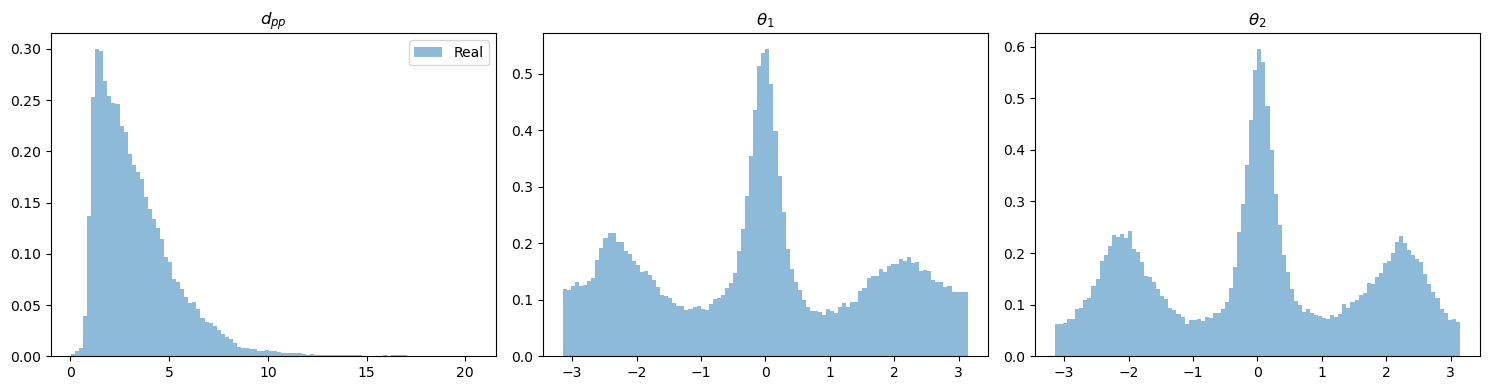

In [39]:

fig, axs = plt.subplots(1, 3, figsize=(15,4))

axs[0].hist(d_pp_c,alpha = 0.5,density = True,label=r'Real', bins=100)

axs[0].legend()
axs[0].set_title(r'$d_{pp}$')

axs[1].hist(wrap_pi(theta_i_c,) ,density = True,alpha = 0.5,bins=100)
axs[1].set_title(r"$\theta_1$")

axs[2].hist(wrap_pi(theta_j_c),density =True, alpha = 0.5,bins=100)


axs[2].set_title(r"$\theta_2$")
plt.tight_layout()
fig_path = os.path.join(outdir, "stochastic_simulation_distributions.png")
plt.show()
#plt.savefig(fig_path, dpi=300)
plt.close()

In [2]:
js_first

np.float64(0.09455796549915896)